In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [100]:
df = pd.read_csv("C:\\Users\\edwin\\OneDrive\\Desktop\\development_journey\\20.Machine Learning\\unsupervised\\kmeans_works\\Mall_Customers.csv.xls")

In [101]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [102]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [103]:
X = df[["Annual Income (k$)","Spending Score (1-100)"]]

In [104]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [105]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X))

In [106]:
wcss = [] #WCSS (Within-Cluster Sum of Squares) # see machine learning docx
K=[]
from sklearn.cluster import KMeans
#It calculates the sum of the squared distances between each data point and its assigned cluster centroid. 
#Lower WCSS values indicate tightly grouped, better-defined clusters.

In [107]:
for i in range(1,11):

    km = KMeans(n_clusters=i,random_state=2,n_init=10)

    km.fit(X)

    print(f"K = {i},WCSS = {km.inertia_}")

    wcss.append(km.inertia_)

    K.append(i)

K = 1,WCSS = 399.99999999999994
K = 2,WCSS = 271.7037332940275
K = 3,WCSS = 195.50501014302682
K = 4,WCSS = 108.92131661364357
K = 5,WCSS = 65.56840815571681
K = 6,WCSS = 57.381747460227864
K = 7,WCSS = 47.7105837613079
K = 8,WCSS = 47.6387253698155
K = 9,WCSS = 32.82802898718322
K = 10,WCSS = 29.922639533086684


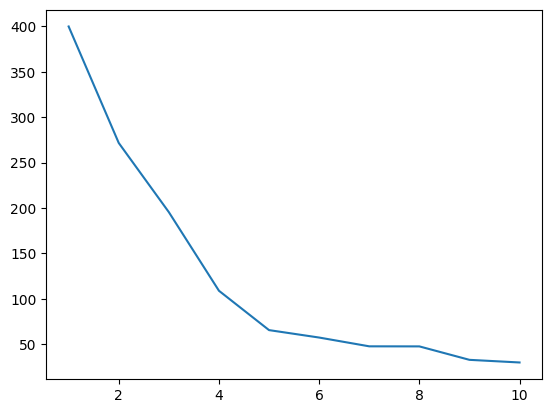

In [108]:
# plt.plot(range(1,11),wcss)
plt.plot(K,wcss)
plt.show() # n_clusters = 5, K=5

In [109]:
km = KMeans(n_clusters=5,random_state=2,n_init=10)
km.fit(X)
Y_pred = km.predict(X)

In [110]:
print(Y_pred)

[2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2
 4 2 4 2 4 2 0 2 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 3 1 3 0 3 1 3 1 3 0 3 1 3 1 3 1 3 1 3 0 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3]


In [111]:
X["Cluster"] = Y_pred

In [112]:
X.head()

,0,1,Cluster
0,-1.738999,-0.434801,2
1,-1.738999,1.195704,4
2,-1.700830,-1.715913,2
3,-1.700830,1.040418,4
4,-1.662660,-0.395980,2


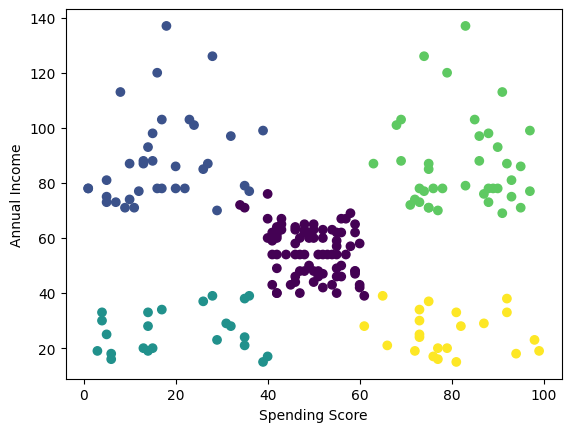

In [113]:
plt.scatter(x=df["Spending Score (1-100)"],y=df["Annual Income (k$)"],c=X["Cluster"])
# Colors each point according to its cluster label.
# This is commonly used after clustering algorithms such as K-Means Clustering.
plt.xlabel("Spending Score")
plt.ylabel("Annual Income")
plt.show()

In [114]:
from sklearn.metrics import silhouette_score # quality of a clustering algorithm (like K-Means)

# score = silhouette_score(
#     X[["Annual Income (k$)", "Spending Score (1-100)"]],
#     Y_pred
# )
print(silhouette_score(X,Y_pred)*100)
# print(score)

69.54793706417628
